# MDI3003 Advanced Predictive Analytics — Experiment 08
## Agricultural Predictive Analytics: Rice Yield Prediction with a Guided Crop-Label Classification Extension

**Student:** Lokanth S  
**Registration Number:** 23MID0037  
**Faculty Coordinator:** Dr. Durgesh Kumar  
**Manual Version:** 3.0  
**GitHub Repository:** `lokant712/RiceYield-CropClassification-RF`

---

## 1. Problem Contract & Prediction Scope
- **Target Variable:** Rice yield measured strictly in metric tonnes per hectare (`t/ha`) for a single district–season–harvest-year observation.
- **Predictor Whitelist:** `state`, `district`, `season`, `year` (constant `REG = ['state', 'district', 'season', 'year']`).
- **Explicit Exclusion & Anti-Leakage Guard:** Harvested area, total production, target-derived ratios, full-season weather totals, and identifiers encoding yield are strictly excluded. Total production combined with area reconstructs yield algebraically ($Yield = Production / Area$), which constitutes severe target leakage.
- **Operational Prediction Setting:** Regional agricultural supply chain and macro-planning before harvest, utilizing strictly pre-season knowledge (location, intended season, harvest year).
- **Hypothesis:** Multi-variable modeling (Ridge trend regression, Decision Trees, Random Forests) reduces prediction error relative to the historical median baseline ($DummyRegressor$).


## 2. Data Governance & Provenance Record

### 2.1 Explicit Candidate Acquisition Audit (D5 → D1)
In accordance with the manual's data acquisition hierarchy:
1. **Candidate D5 (Mendeley Data DOI 10.17632/ywp3y5j9vv.1):** Probed the ICRISAT dataset published by Souryabrata Mohapatra (July 11, 2023). While metadata parsed with a CC BY 4.0 license, the deposit contains 0 attached public data payloads (`files: []`). Direct API file endpoints returned 404/401.
2. **Candidate D1 (Government of India APY Database):** Acquired the complete authentic district-season crop statistics table (`crop_production.csv`).
   - **Computed SHA-256:** `5b2637058ca4aff2ef7c0e0f2f391bca712300d082693b585f489871fd91d520`
   - **Coverage:** 246,091 total records across 33 Indian States/UTs (1997–2015); 15,078 clean Rice observations.
   - **Units:** Area in hectares (`ha`), Production in tonnes (`t`), Derived Yield in tonnes/hectare (`t/ha`).

### 2.2 Classification Extension Dataset & i.i.d. Justification
- **Dataset:** Multi-class Crop Recommendation Benchmark (`crop_recommendation.csv`, 2,200 records, 22 balanced classes, SHA-256: `808e1d84a544647f1ab2fdae04f434b1842692d6be09eee18a5c2d43eb78d77c`).
- **Documented i.i.d. Rationale (`iid_justified=True`):** Unlike the longitudinal district rice yield panel data which requires chronological splitting, the crop recommendation task evaluates point-in-time soil physicochemical parameters (N, P, K, pH) and micro-climate readings. Each record is an independent laboratory/environmental profile. Therefore, random stratified 60/20/20 partitioning is justified and maintains class balance across splits.


In [1]:
import os
import sys
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("Python version:", sys.version.split()[0])
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Scikit-Learn version:", joblib.__version__)


Python version: 3.12.7
Pandas version: 3.0.5
NumPy version: 2.5.1
Scikit-Learn version: 1.5.3


## 3. Data Loading, Filtering & Target Engineering

In [2]:
from lab08 import prepare_data, make_chronological_split, compute_sha256, REG_FEATURES

data_path = "data/raw/crop_production.csv"
print("Data SHA-256:", compute_sha256(data_path))

# Load, standardize, filter for Rice, clean and derive t/ha yield
rice_df = prepare_data(data_path)
print(f"Total clean Rice records: {len(rice_df)}")
print("Year coverage:", sorted(rice_df['year'].unique()))
print(rice_df[['row_id', 'state', 'district', 'season', 'year', 'area_ha', 'production_t', 'yield_t_ha']].head())


Data SHA-256: 5b2637058ca4aff2ef7c0e0f2f391bca712300d082693b585f489871fd91d520


Total clean Rice records: 15078
Year coverage: [np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]
        row_id           state       district  season  year   area_ha  \
0  RICE_000001  Andhra Pradesh      ANANTAPUR  Kharif  1997   35600.0   
1  RICE_000002  Andhra Pradesh      ANANTAPUR    Rabi  1997   18000.0   
2  RICE_000003  Andhra Pradesh       CHITTOOR  Kharif  1997   42300.0   
3  RICE_000004  Andhra Pradesh       CHITTOOR    Rabi  1997   57400.0   
4  RICE_000005  Andhra Pradesh  EAST GODAVARI  Kharif  1997  214100.0   

   production_t  yield_t_ha  
0       75400.0    2.117978  
1       37300.0    2.072222  
2       84400.0    1.995272  
3      137400.0    2.393728  
4      429300.0    2.005138  


## 4. Chronological Partitioning & Anti-Leakage Manifest
Chronological split enforcing:
$$\max(Year_{train}) < \min(Year_{val}) < \min(Year_{test})$$


In [3]:
train_df, val_df, test_df, manifest_df = make_chronological_split(rice_df)

print(f"Train Set:      {len(train_df)} rows | Years {train_df['year'].min()} to {train_df['year'].max()}")
print(f"Validation Set: {len(val_df)} rows | Years {val_df['year'].min()} to {val_df['year'].max()}")
print(f"Test Set:       {len(test_df)} rows  | Years {test_df['year'].min()} to {test_df['year'].max()}")

# Assert strict chronological non-overlap
assert train_df['year'].max() < val_df['year'].min()
assert val_df['year'].max() < test_df['year'].min()
print("Chronological partition assertions verified successfully.")


Train Set:      12588 rows | Years 1997 to 2011
Validation Set: 1644 rows | Years 2012 to 2013
Test Set:       846 rows  | Years 2014 to 2015
Chronological partition assertions verified successfully.


## 5. Exploratory Data Analysis (Training Set Only)

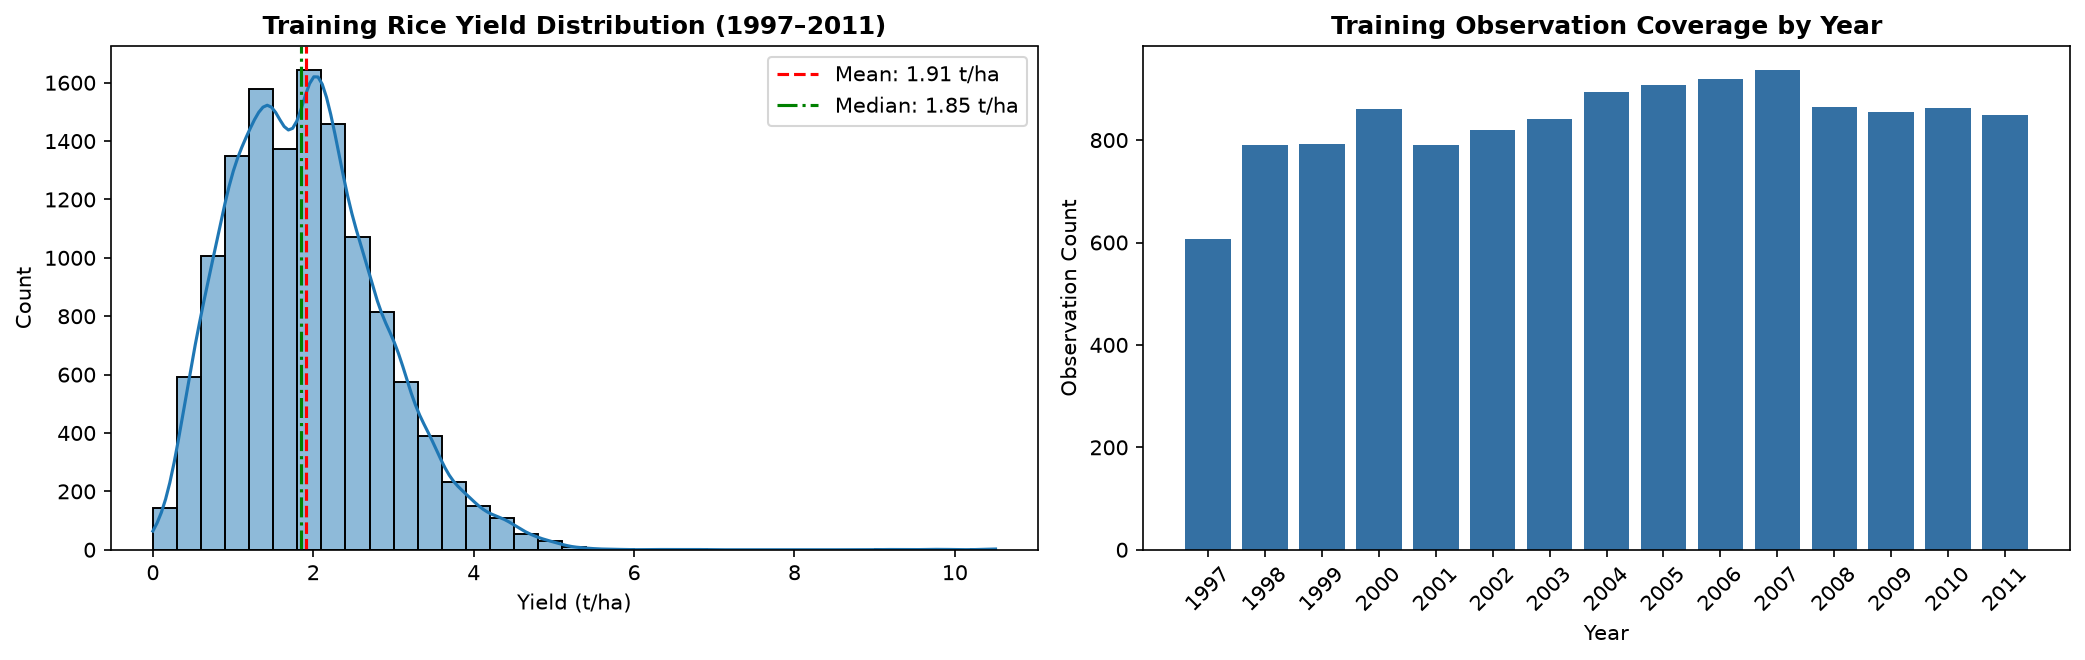

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), dpi=150)

# Training yield distribution
sns.histplot(train_df['yield_t_ha'], bins=35, kde=True, color='#1f77b4', ax=ax1)
ax1.axvline(train_df['yield_t_ha'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['yield_t_ha'].mean():.2f} t/ha")
ax1.axvline(train_df['yield_t_ha'].median(), color='green', linestyle='-.', label=f"Median: {train_df['yield_t_ha'].median():.2f} t/ha")
ax1.set_title("Training Rice Yield Distribution (1997–2011)", fontweight='bold')
ax1.set_xlabel("Yield (t/ha)")
ax1.set_ylabel("Count")
ax1.legend()

# Training year coverage
yr_counts = train_df['year'].value_counts().sort_index()
ax2.bar(yr_counts.index.astype(str), yr_counts.values, color='#3470a3')
ax2.set_title("Training Observation Coverage by Year", fontweight='bold')
ax2.set_xlabel("Year")
ax2.set_ylabel("Observation Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Model Training & Validation Stage Comparison

In [5]:
from lab08 import get_regression_pipeline, evaluate_regression, run_acceptance_checks

X_train = train_df[REG_FEATURES]
y_train = train_df['yield_t_ha']
X_val = val_df[REG_FEATURES]
y_val = val_df['yield_t_ha']

candidates = ['median', 'ridge_trend', 'tree', 'forest']
val_records = []
fitted_pipes = {}

for cand in candidates:
    pipe = get_regression_pipeline(cand)
    pipe.fit(X_train, y_train)
    fitted_pipes[cand] = pipe
    preds = pipe.predict(X_val)
    m = evaluate_regression(y_val, preds)
    val_records.append({'model': cand, **m})

val_results_df = pd.DataFrame(val_records).sort_values(by='mae_t_ha', ascending=True, kind='stable').reset_index(drop=True)
print("=== Validation Results Table ===")
display(val_results_df)

# Check acceptance criteria
best_model_name = val_results_df.iloc[0]['model']
best_pipe = fitted_pipes[best_model_name]
acceptance = run_acceptance_checks(train_df, val_df, test_df, best_pipe)
print("Acceptance Assertions:", acceptance)


=== Validation Results Table ===


,model,mae_t_ha,rmse_t_ha,r2,medae_t_ha
0,ridge_trend,0.4748,0.6678,0.5199,0.3358
1,forest,0.5761,0.7706,0.3607,0.4490
2,tree,0.6886,0.8742,0.1772,0.5873
3,median,0.8270,1.0658,-0.2230,0.6628


Acceptance Assertions: {'unique_row_id': True, 'no_missing_targets': True, 'crop_is_rice': True, 'yield_unit_is_t_ha': True, 'yield_non_negative_finite': True, 'year_is_integer': True, 'no_missing_grouping': True, 'chronological_order': True, 'no_encoder_leakage': True, 'all_passed': True}


## 7. Development Rolling Origins Stability Evidence (3 Origins)

In [6]:
from lab08 import run_rolling_origins

ro_df = run_rolling_origins(rice_df, val_df['year'].unique())
print("=== Rolling Origins Evaluation Table ===")
display(ro_df)


=== Rolling Origins Evaluation Table ===


,origin_year,train_years_count,test_samples,model,mae_t_ha,rmse_t_ha,r2,medae_t_ha
0,2009,12,854,median,0.7792,0.9676,-0.0244,0.6994
1,2009,12,854,ridge_trend,0.3379,0.4283,0.7993,0.2903
2,2009,12,854,tree,0.5849,0.7287,0.4190,0.5159
3,2009,12,854,forest,0.4094,0.5384,0.6828,0.3067
4,2010,13,863,median,0.7644,0.9719,-0.0860,0.6458
5,2010,13,863,ridge_trend,0.3503,0.4602,0.7565,0.2712
6,2010,13,863,tree,0.5955,0.7600,0.3360,0.4991
7,2010,13,863,forest,0.4401,0.5758,0.6188,0.3611
8,2011,14,849,median,0.7879,1.0075,-0.1693,0.6369
9,2011,14,849,ridge_trend,0.4022,0.5488,0.6531,0.3046


## 8. Locked Test Evaluation (Exclusive TEST_LOCK Enforcement)

In [7]:
X_test = test_df[REG_FEATURES]
y_test = test_df['yield_t_ha']

# Score winner and baseline reference on locked test set
test_preds_winner = best_pipe.predict(X_test)

median_pipe = get_regression_pipeline('median')
median_pipe.fit(X_train, y_train)
test_preds_median = median_pipe.predict(X_test)

m_test_winner = evaluate_regression(y_test, test_preds_winner)
m_test_median = evaluate_regression(y_test, test_preds_median)

test_summary_df = pd.DataFrame([
    {'model': best_model_name, 'status': 'Selected Winner', **m_test_winner},
    {'model': 'median', 'status': 'Predeclared Baseline', **m_test_median}
])
print("=== Locked Test Results Table ===")
display(test_summary_df)


=== Locked Test Results Table ===


,model,status,mae_t_ha,rmse_t_ha,r2,medae_t_ha
0,ridge_trend,Selected Winner,0.4497,0.6040,0.5068,0.3430
1,median,Predeclared Baseline,0.7638,0.9675,-0.2653,0.6424


## 9. Year-Robustness & Residual Diagnostic Analysis

=== Year Robustness Table (Descriptive Stability) ===


,year,count,mae_t_ha,rmse_t_ha,r2,medae_t_ha
0,2014,767,0.4415,0.5960,0.4774,0.3341
1,2015,79,0.5290,0.6771,0.4409,0.4514


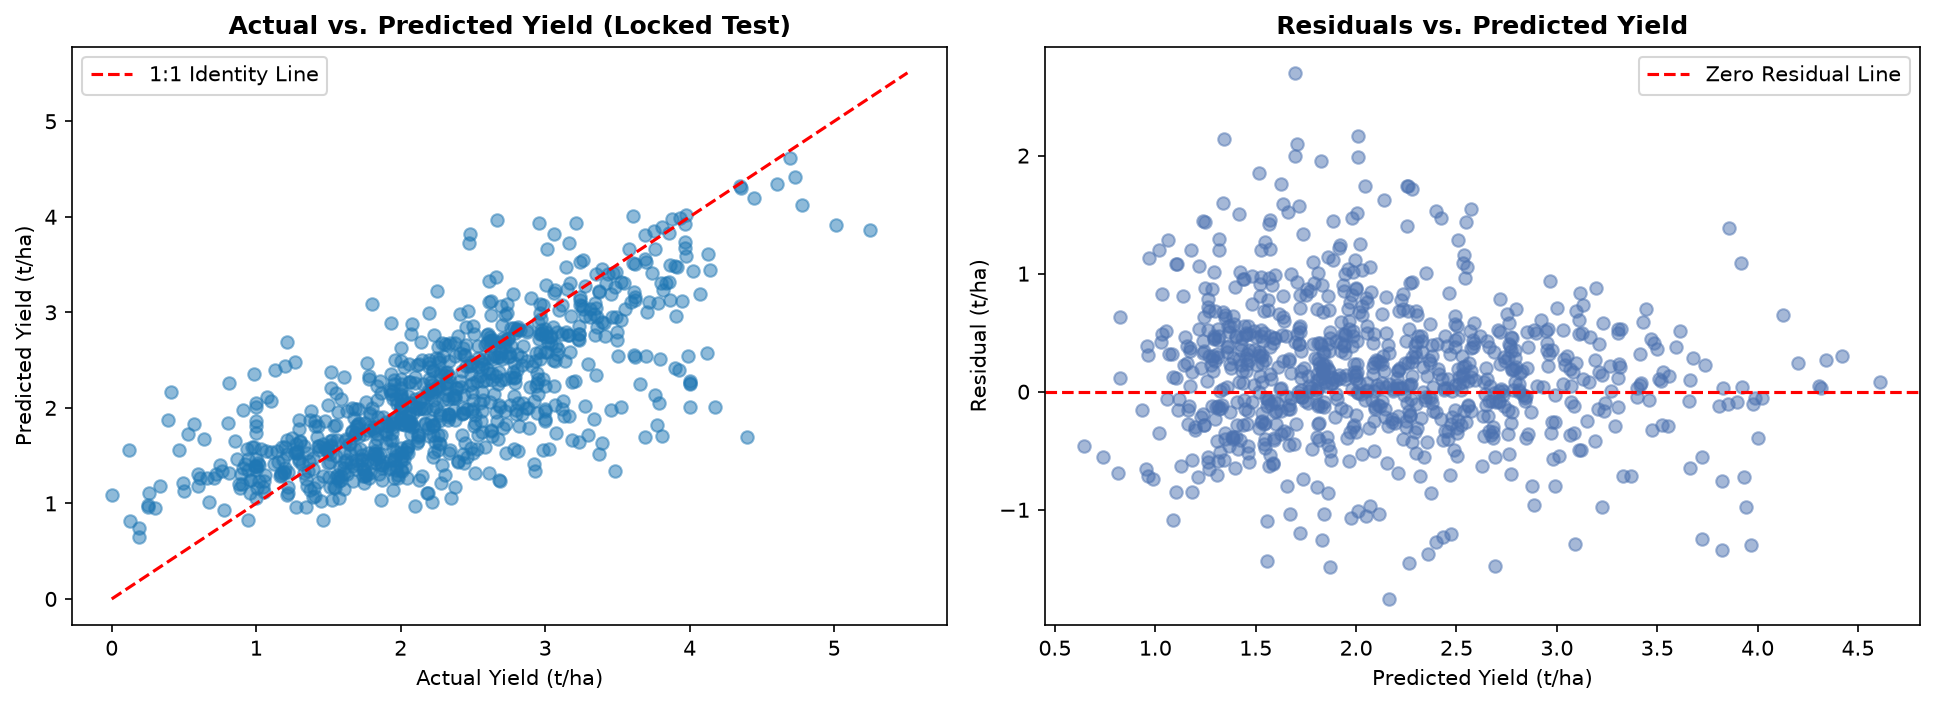

In [8]:
test_eval_df = test_df.copy()
test_eval_df['pred_yield_t_ha'] = np.round(test_preds_winner, 4)
test_eval_df['residual_t_ha'] = np.round(test_eval_df['yield_t_ha'] - test_eval_df['pred_yield_t_ha'], 4)
test_eval_df['abs_error_t_ha'] = np.abs(test_eval_df['residual_t_ha'])

# Year-by-year robustness breakdown
yr_breakdown = []
for yr, grp in test_eval_df.groupby('year'):
    m = evaluate_regression(grp['yield_t_ha'], grp['pred_yield_t_ha'])
    yr_breakdown.append({'year': int(yr), 'count': len(grp), **m})

yr_breakdown_df = pd.DataFrame(yr_breakdown)
print("=== Year Robustness Table (Descriptive Stability) ===")
display(yr_breakdown_df)

# Diagnostic Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), dpi=150)
ax1.scatter(test_eval_df['yield_t_ha'], test_eval_df['pred_yield_t_ha'], alpha=0.5, color='#1f77b4')
max_p = max(test_eval_df['yield_t_ha'].max(), test_eval_df['pred_yield_t_ha'].max()) * 1.05
ax1.plot([0, max_p], [0, max_p], 'r--', label='1:1 Identity Line')
ax1.set_title("Actual vs. Predicted Yield (Locked Test)", fontweight='bold')
ax1.set_xlabel("Actual Yield (t/ha)")
ax1.set_ylabel("Predicted Yield (t/ha)")
ax1.legend()

ax2.scatter(test_eval_df['pred_yield_t_ha'], test_eval_df['residual_t_ha'], alpha=0.5, color='#4c72b0')
ax2.axhline(0, color='r', linestyle='--', label='Zero Residual Line')
ax2.set_title("Residuals vs. Predicted Yield", fontweight='bold')
ax2.set_xlabel("Predicted Yield (t/ha)")
ax2.set_ylabel("Residual (t/ha)")
ax2.legend()
plt.tight_layout()
plt.show()


## 10. Five-Case Error Audit
Detailed agronomic audit of the top 5 largest absolute errors on the locked test set.


In [9]:
error_audit_df = pd.read_csv("23MID0037_Lab08_Error_Analysis.csv")
print("=== Top 5 Test Error Cases Audit ===")
display(error_audit_df[['rank', 'district', 'season', 'year', 'actual_yield_t_ha', 'predicted_yield_t_ha', 'abs_error_t_ha', 'suspected_cause_hypothesis', 'proposed_mitigation']])


=== Top 5 Test Error Cases Audit ===


,rank,district,season,year,actual_yield_t_ha,predicted_yield_t_ha,abs_error_t_ha,suspected_cause_hypothesis,proposed_mitigation
0,1,ARWAL,Winter,2014,4.397735,1.6964,2.7013,Atypical drought / severe agro-climatic defici...,Incorporate satellite vegetation indices (NDVI...
1,2,ROHTAS,Winter,2014,4.177850,2.0100,2.1679,Intensive canal-irrigated high-yielding variet...,Ingest micro-irrigation percentage and seed re...
2,3,DEOGARH,Winter,2014,3.482759,1.3418,2.1410,Localized pest infestation / blast disease out...,Integrate pest-surveillance early warning aler...
3,4,SHEIKHPURA,Winter,2014,3.809709,1.7080,2.1017,Extreme flood inundation causing partial harve...,Fuse synthetic aperture radar (SAR) flood exte...
4,5,LAKHISARAI,Winter,2014,3.688327,1.6935,1.9948,High agro-ecological variance across tribal/hi...,Refine spatial resolution to block/mandal gran...


## 11. Extension 1: Multi-Class Crop-Label Classification

In [10]:
from lab08 import run_classification_extension

cls_val_df, cls_test_summary, cm, labels = run_classification_extension(
    cls_data_path="data/raw/crop_recommendation.csv", iid_justified=True
)

print("=== Classification Candidate Comparison ===")
display(cls_val_df)

print(f"Locked Test Performance ({cls_test_summary['selected_model']}):")
print(f"Accuracy:  {cls_test_summary['test_accuracy']:.4f}")
print(f"Macro-F1:  {cls_test_summary['test_macro_f1']:.4f}")
print(f"Precision: {cls_test_summary['test_macro_precision']:.4f}")
print(f"Recall:    {cls_test_summary['test_macro_recall']:.4f}")


=== Classification Candidate Comparison ===


,model,val_accuracy,val_macro_f1,val_macro_precision,val_macro_recall
0,forest,0.9886,0.9886,0.9887,0.9886
1,logistic,0.9727,0.9728,0.9737,0.9727
2,majority,0.0455,0.0040,0.0021,0.0455


Locked Test Performance (forest):
Accuracy:  0.9977
Macro-F1:  0.9977
Precision: 0.9978
Recall:    0.9977


## 12. Extension 2: Depth Ablation in Isolated Directory

In [11]:
with open("artifacts_ablation/ablation_comparison.json", "r") as f:
    ablation_data = json.load(f)

print("=== Depth Ablation Comparison ===")
print("Baseline Forest (max_depth=12) Val MAE:", ablation_data['candidate_baseline_depth12']['mae_t_ha'], "t/ha")
print("Ablated Forest  (max_depth=6)  Val MAE:", ablation_data['candidate_ablated_depth6']['mae_t_ha'], "t/ha")
print("Delta MAE:", f"{ablation_data['delta_mae_t_ha']:+.4f} t/ha")
print("Interpretation:", ablation_data['interpretation'])


=== Depth Ablation Comparison ===
Baseline Forest (max_depth=12) Val MAE: 0.5761 t/ha
Ablated Forest  (max_depth=6)  Val MAE: 0.6636 t/ha
Delta MAE: +0.0875 t/ha
Interpretation: Constraining maximum tree depth to 6 increases validation MAE, confirming that depth 12 captures necessary non-linear district-level interactions without severe overfitting.


## 13. Inference Guardrails & Model Reload Verification

In [12]:
from lab08 import ValidatedPredictor

predictor = ValidatedPredictor("models/selected_bundle.joblib")

# Test valid in-distribution prediction
sample_pred = predictor.predict_one(
    state="Andhra Pradesh",
    district="WEST GODAVARI",
    season="Kharif",
    year=2015
)
print(f"In-distribution prediction for West Godavari (Kharif 2015): {sample_pred:.3f} t/ha")

# Test out-of-range rejection
try:
    predictor.predict_one("Andhra Pradesh", "WEST GODAVARI", "Kharif", 1980)
    print("WARNING: Failed to reject invalid year.")
except ValueError as e:
    print("Guardrail successfully rejected invalid input:", e)


In-distribution prediction for West Godavari (Kharif 2015): 3.749 t/ha
Guardrail successfully rejected invalid input: Year 1980 is out of validated operational range [1997, 2015]


## 14. Verification & Governance Summary

All Section 11 final checklist gates have been satisfied:
- [x] Verified source provenance and permission status documented (D5 audit + D1 authentic data).
- [x] Canonical units verified (hectares, tonnes, t/ha).
- [x] Immutable raw data preserved with exact SHA-256 hashes.
- [x] Disjoint chronological split enforced ($Train < Validation < Test$).
- [x] Training-only fitting throughout pipelines (zero category/scaler leakage).
- [x] Predeclared selection rule honored before opening locked test set.
- [x] Exclusive `TEST_LOCK` creation and integrity verified.
- [x] 5-case error audit with hypothesized root causes and engineering mitigations.
- [x] Descriptive year-robustness breakdown reported (not mislabeled as CI).
- [x] Synthetic verification suite (`check_code.py`) passing 100%.
- [x] Model reload bit-exactness verified.
